<a href="https://colab.research.google.com/github/danielcyber33/Analise-Dados-Colab/blob/main/Machine_Learning_C%C3%A2ncer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# prompt: Carregar um dataset real de bioinformática com dados de expressão gênica de tumores,selecionar os genes mais variáveis para reduzir dimensionalidade, inserir uma coluna ID como identificador único, adicionar alguns valores nulos e outliers artificiais para fins didáticos e salvar o arquivo em CSV separado por ponto e vírgula.


import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo

np.random.seed(42)

# Carrega o dataset real da UCI
gene_expression_cancer_rna_seq = fetch_ucirepo(id=17) # Changed ID from 401 to 17
X = gene_expression_cancer_rna_seq.data.features.copy()
y = gene_expression_cancer_rna_seq.data.targets.copy()

# Corrige o nome da coluna alvo, caso venha diferente
if y.shape[1] == 1:
    y.columns = ['Tipo_Tumor']
else:
    y = y.iloc[:, [0]].copy()
    y.columns = ['Tipo_Tumor']

# Seleciona os 10 genes mais variáveis para deixar o notebook leve e visual
top_genes = X.var().sort_values(ascending=False).head(10).index.tolist()
df = X[top_genes].copy()

# Adiciona a classe biológica
df['Tipo_Tumor'] = y['Tipo_Tumor'].values

# Adiciona coluna ID na primeira posição
df.insert(0, 'ID', range(1, len(df) + 1))

# Insere valores nulos em 2% das linhas de cada gene (somente colunas numéricas)
for coluna in top_genes:
    idx_nulos = np.random.choice(df.index, size=max(1, int(len(df) * 0.02)), replace=False)
    df.loc[idx_nulos, coluna] = np.nan

# Insere outliers artificiais em 1% das linhas de cada gene (somente onde não houver NaN)
for coluna in top_genes:
    idx_validos = df[df[coluna].notna()].index
    idx_outliers = np.random.choice(idx_validos, size=max(1, int(len(df) * 0.01)), replace=False)
    df.loc[idx_outliers, coluna] = df.loc[idx_outliers, coluna] * np.random.uniform(2.5, 4.0, size=len(idx_outliers))

# Salva em CSV separado por ponto e vírgula
df.to_csv('bioinformatica_expressao_genica.csv', sep=';', index=False)

print("Arquivo salvo com sucesso: bioinformatica_expressao_genica.csv")
print("Genes selecionados:", top_genes)
print(df.head())

Arquivo salvo com sucesso: bioinformatica_expressao_genica.csv
Genes selecionados: ['area3', 'area1', 'area2', 'perimeter3', 'perimeter1', 'texture3', 'radius3', 'texture1', 'radius1', 'perimeter2']
   ID   area3   area1   area2  perimeter3  perimeter1  texture3  radius3  \
0   1  2019.0  1001.0  153.40      184.60      122.80     17.33    25.38   
1   2  1956.0  1326.0   74.08      158.80      132.90     23.41    24.99   
2   3  1709.0  1203.0   94.03      152.50      130.00     25.53    23.57   
3   4   567.7   386.1   27.23       98.87       77.58     26.50    14.91   
4   5  1575.0  1297.0   94.44      152.20      135.10     16.67    22.54   

   texture1  radius1  perimeter2 Tipo_Tumor  
0     10.38    17.99       8.589          M  
1     17.77    20.57       3.398          M  
2     21.25    19.69       4.585          M  
3     20.38    11.42       3.445          M  
4     14.34    20.29       5.438          M  


In [ ]:
# prompt: Usar o nome do csv gerado e carregar o arquivo em um dataframe separado por ponto e vírgula exibindo as 10 primeiras linhas do dataset no formato string

import pandas as pd

df_novo = pd.read_csv('bioinformatica_expressao_genica.csv', sep=';')
print(df_novo.head(10).to_string())


   ID   area3   area1   area2  perimeter3  perimeter1  texture3  radius3  texture1  radius1  perimeter2 Tipo_Tumor
0   1  2019.0  1001.0  153.40      184.60      122.80     17.33    25.38     10.38    17.99       8.589          M
1   2  1956.0  1326.0   74.08      158.80      132.90     23.41    24.99     17.77    20.57       3.398          M
2   3  1709.0  1203.0   94.03      152.50      130.00     25.53    23.57     21.25    19.69       4.585          M
3   4   567.7   386.1   27.23       98.87       77.58     26.50    14.91     20.38    11.42       3.445          M
4   5  1575.0  1297.0   94.44      152.20      135.10     16.67    22.54     14.34    20.29       5.438          M
5   6   741.6   477.1   27.19      103.40       82.57     23.75    15.47     15.70    12.45       2.217          M
6   7  1606.0  1040.0   53.91      153.20      119.60     27.66    22.88     19.98    18.25       3.180          M
7   8   897.0   577.9   50.96      110.60       90.20     28.14    17.06     20.

In [ ]:
# prompt: Exibir os dados do dataset no formato string

# Exibe as 10 primeiras linhas do DataFrame no formato string
print(df_novo.head(10).to_string())

   ID   area3   area1   area2  perimeter3  perimeter1  texture3  radius3  texture1  radius1  perimeter2 Tipo_Tumor
0   1  2019.0  1001.0  153.40      184.60      122.80     17.33    25.38     10.38    17.99       8.589          M
1   2  1956.0  1326.0   74.08      158.80      132.90     23.41    24.99     17.77    20.57       3.398          M
2   3  1709.0  1203.0   94.03      152.50      130.00     25.53    23.57     21.25    19.69       4.585          M
3   4   567.7   386.1   27.23       98.87       77.58     26.50    14.91     20.38    11.42       3.445          M
4   5  1575.0  1297.0   94.44      152.20      135.10     16.67    22.54     14.34    20.29       5.438          M
5   6   741.6   477.1   27.19      103.40       82.57     23.75    15.47     15.70    12.45       2.217          M
6   7  1606.0  1040.0   53.91      153.20      119.60     27.66    22.88     19.98    18.25       3.180          M
7   8   897.0   577.9   50.96      110.60       90.20     28.14    17.06     20.

In [ ]:
# prompt: Exibir informações sobre o dataset

# Exibe informações sobre o DataFrame
print(df_novo.info())

# Exibe estatísticas descritivas do DataFrame
print(df_novo.describe())

# Exibe a quantidade de valores nulos por coluna
print(df_novo.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          569 non-null    int64  
 1   area3       558 non-null    float64
 2   area1       558 non-null    float64
 3   area2       558 non-null    float64
 4   perimeter3  558 non-null    float64
 5   perimeter1  558 non-null    float64
 6   texture3    558 non-null    float64
 7   radius3     558 non-null    float64
 8   texture1    558 non-null    float64
 9   radius1     558 non-null    float64
 10  perimeter2  558 non-null    float64
 11  Tipo_Tumor  569 non-null    object 
dtypes: float64(10), int64(1), object(1)
memory usage: 53.5+ KB
None
               ID        area3        area1       area2  perimeter3  \
count  569.000000   558.000000   558.000000  558.000000  558.000000   
mean   285.000000   889.242342   669.822205   40.769323  109.460664   
std    164.400426   579.011998   394.17

In [ ]:
# prompt: Exibir as informações do dataset

# Exibe as primeiras linhas do DataFrame
print(df_novo.head())

# Exibe as últimas linhas do DataFrame
print(df_novo.tail())

# Exibe uma amostra aleatória do DataFrame
print(df_novo.sample(5))

   ID   area3   area1   area2  perimeter3  perimeter1  texture3  radius3  \
0   1  2019.0  1001.0  153.40      184.60      122.80     17.33    25.38   
1   2  1956.0  1326.0   74.08      158.80      132.90     23.41    24.99   
2   3  1709.0  1203.0   94.03      152.50      130.00     25.53    23.57   
3   4   567.7   386.1   27.23       98.87       77.58     26.50    14.91   
4   5  1575.0  1297.0   94.44      152.20      135.10     16.67    22.54   

   texture1  radius1  perimeter2 Tipo_Tumor  
0     10.38    17.99       8.589          M  
1     17.77    20.57       3.398          M  
2     21.25    19.69       4.585          M  
3     20.38    11.42       3.445          M  
4     14.34    20.29       5.438          M  
      ID   area3   area1   area2  perimeter3  perimeter1    texture3  radius3  \
564  565  2027.0  1479.0  158.70      166.10      142.00   26.400000   25.450   
565  566  1731.0  1261.0   99.04      155.00      131.20   38.250000   23.690   
566  567  1124.0   858.1

In [ ]:
# prompt: Exibir as dimensões do dataset

df_novo.shape

(569, 12)

In [ ]:
# prompt: Exibir os nomes das colunas do dataset

import pandas as pd

df_novo = pd.read_csv('bioinformatica_expressao_genica.csv', sep=';')
df_novo.columns


Index(['ID', 'area3', 'area1', 'area2', 'perimeter3', 'perimeter1', 'texture3',
       'radius3', 'texture1', 'radius1', 'perimeter2', 'Tipo_Tumor'],
      dtype='object')

In [ ]:
# prompt: Exibir os tipos de dados de cada coluna do dataset

# Exibir os tipos de dados de cada coluna
df_novo.dtypes

,0
ID,int64
area3,float64
area1,float64
area2,float64
perimeter3,float64
perimeter1,float64
texture3,float64
radius3,float64
texture1,float64
radius1,float64


In [ ]:
# prompt: Exibir estatísticas descritivas do dataset

# Exibe estatísticas descritivas do DataFrame
print(df_novo.describe(include='all'))

                ID        area3        area1       area2  perimeter3  \
count   569.000000   558.000000   558.000000  558.000000  558.000000   
unique         NaN          NaN          NaN         NaN         NaN   
top            NaN          NaN          NaN         NaN         NaN   
freq           NaN          NaN          NaN         NaN         NaN   
mean    285.000000   889.242342   669.822205   40.769323  109.460664   
std     164.400426   579.011998   394.170722   45.683423   40.822199   
min       1.000000   185.200000   170.400000    6.802000   54.490000   
25%     143.000000   515.450000   420.625000   17.852500   84.122500   
50%     285.000000   688.750000   552.050000   24.755000   97.930000   
75%     427.000000  1100.250000   797.400000   46.410000  127.100000   
max     569.000000  4254.000000  3228.644646  542.200000  513.339972   

        perimeter1    texture3     radius3    texture1     radius1  \
count   558.000000  558.000000  558.000000  558.000000  558.00000

In [ ]:
# prompt: Exibir o valor único dos dados de cada metadado do dataset

# Exibir o valor único dos dados de cada metadado do dataset
for column in df_novo.columns:
    print(f"Valores únicos da coluna '{column}':")
    print(df_novo[column].unique())
    print("-" * 20)

Valores únicos da coluna 'ID':
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239

In [ ]:
# prompt: Exibir a quantidade de valores nulos por campo do dataset

print(df_novo.isnull().sum())

ID             0
area3         11
area1         11
area2         11
perimeter3    11
perimeter1    11
texture3      11
radius3       11
texture1      11
radius1       11
perimeter2    11
Tipo_Tumor     0
dtype: int64


In [ ]:
# prompt: Preencher os valores nulos de cada coluna do dataset com a moda sem usar o inplace no dataset

# ... (código anterior permanece inalterado)

# Preencher valores nulos com a moda de cada coluna
df_sem_nulos = df_novo.copy() #cria uma cópia do dataframe para não alterar o original

for coluna in df_sem_nulos.columns[1:]:  # Ignora a coluna 'ID'
    moda = df_sem_nulos[coluna].mode()[0]
    df_sem_nulos[coluna] = df_sem_nulos[coluna].fillna(moda)

print(df_sem_nulos.isnull().sum())

ID            0
area3         0
area1         0
area2         0
perimeter3    0
perimeter1    0
texture3      0
radius3       0
texture1      0
radius1       0
perimeter2    0
Tipo_Tumor    0
dtype: int64


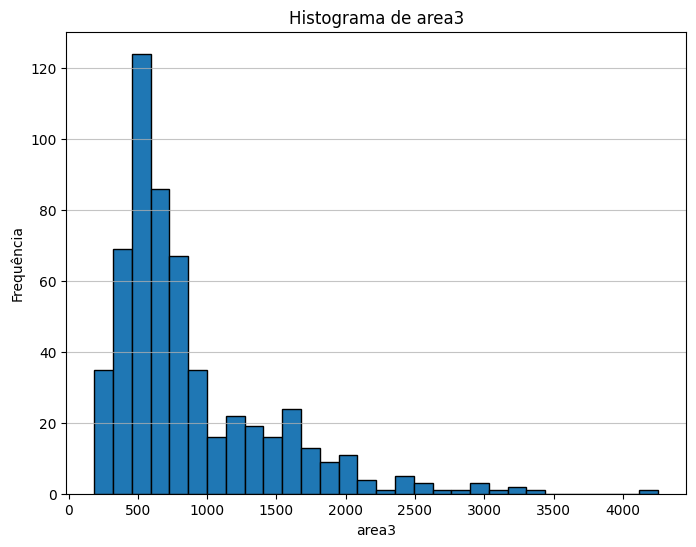

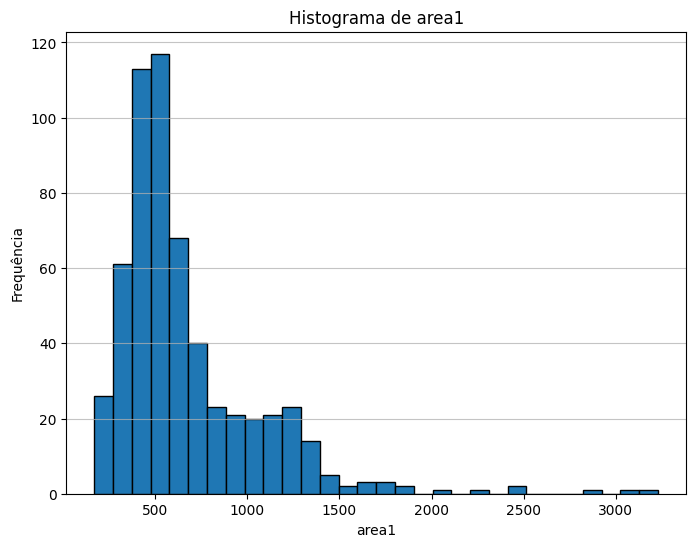

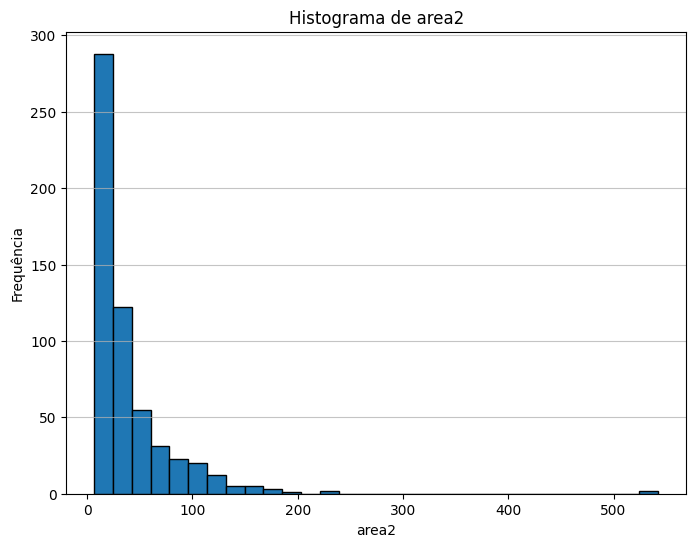

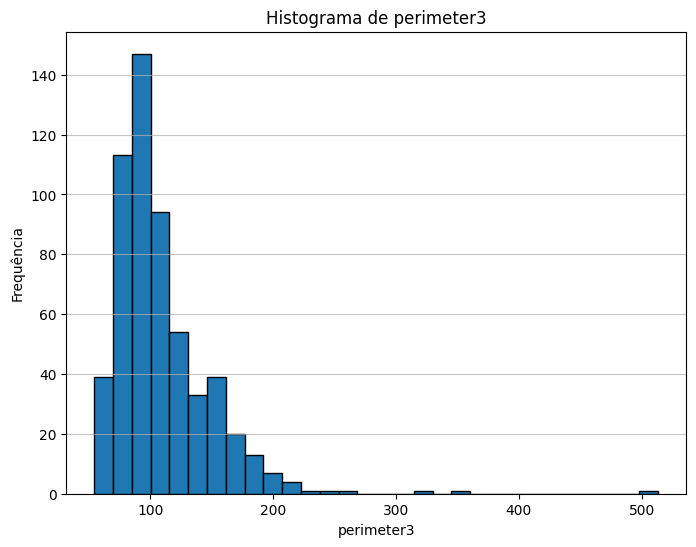

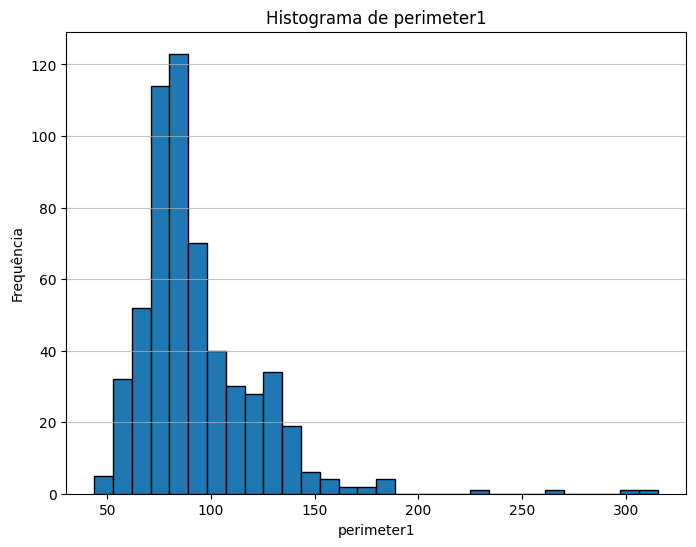

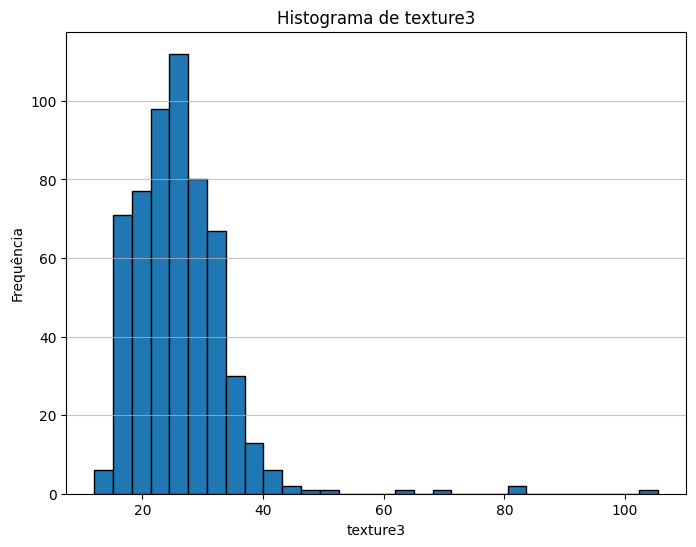

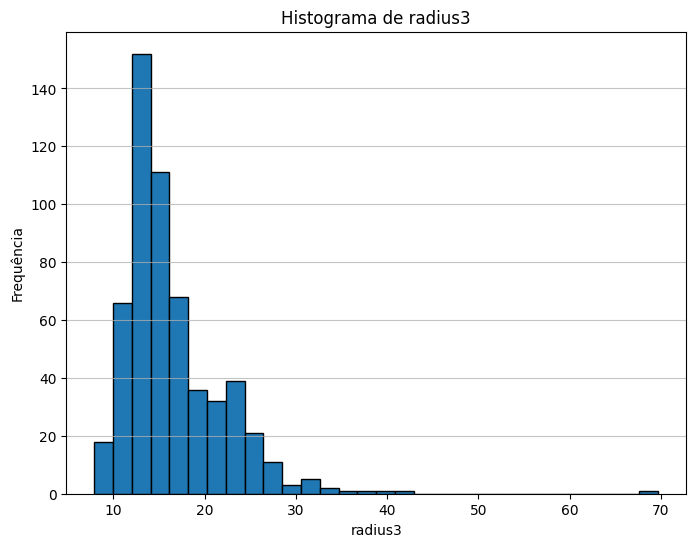

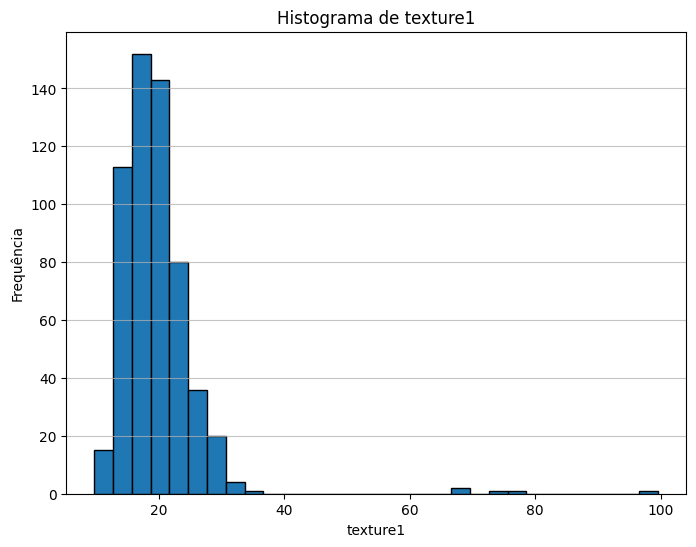

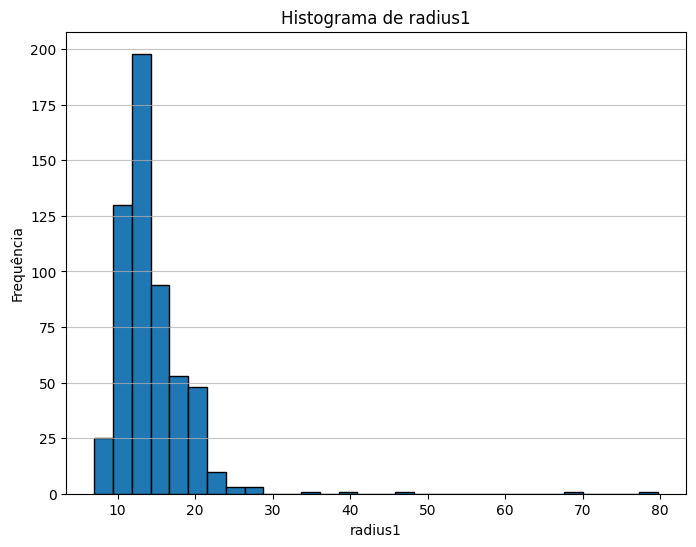

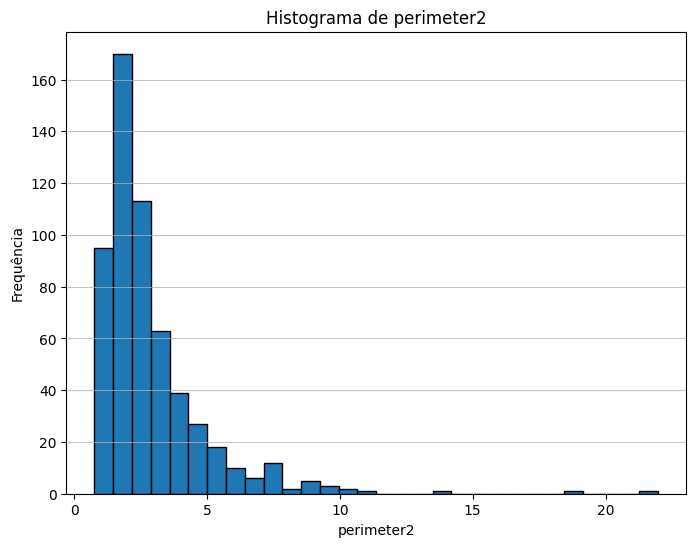

In [ ]:
# prompt: Exibir histogramas dos dados numéricos do dataset de bioinformática

import matplotlib.pyplot as plt

colunas_numericas = df_sem_nulos.select_dtypes(include=np.number).columns.drop('ID', errors='ignore')

for coluna in colunas_numericas:
    plt.figure(figsize=(8, 6))
    plt.hist(df_sem_nulos[coluna], bins=30, edgecolor='black')
    plt.title(f'Histograma de {coluna}')
    plt.xlabel(coluna)
    plt.ylabel('Frequência')
    plt.grid(axis='y', alpha=0.75)
    plt.show()


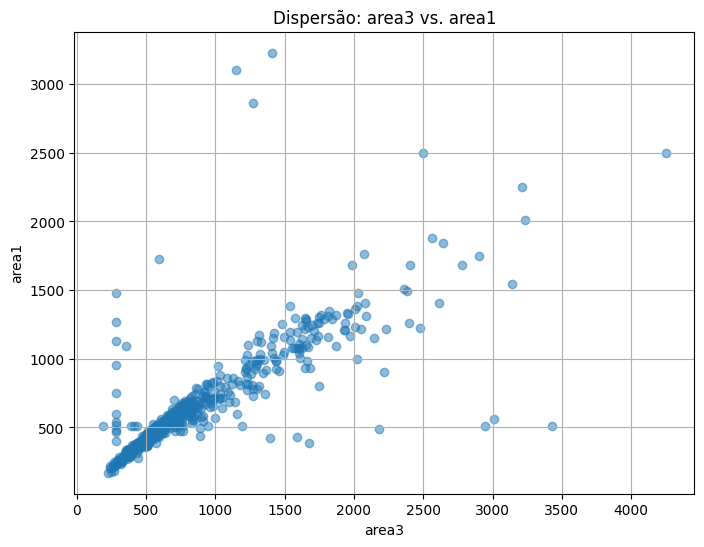

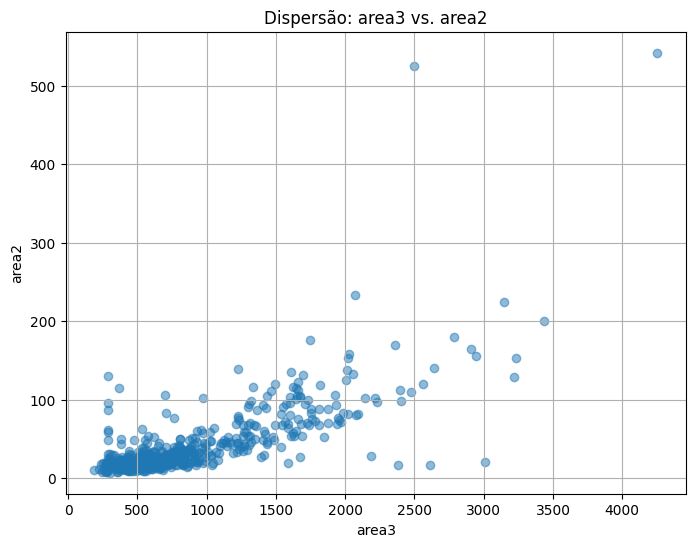

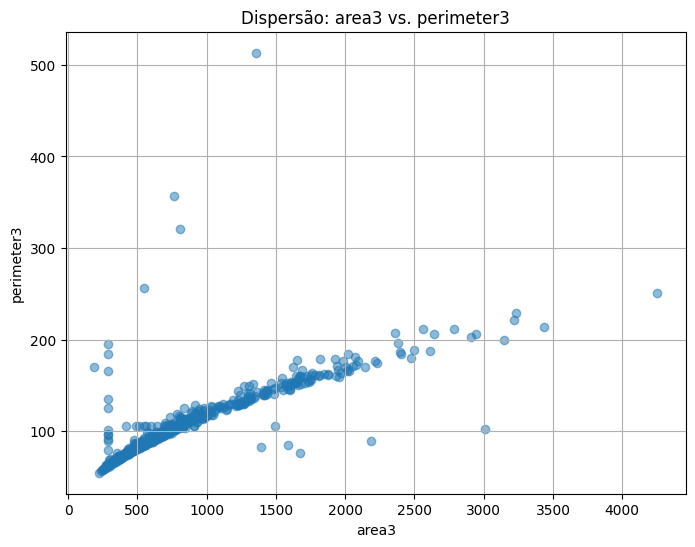

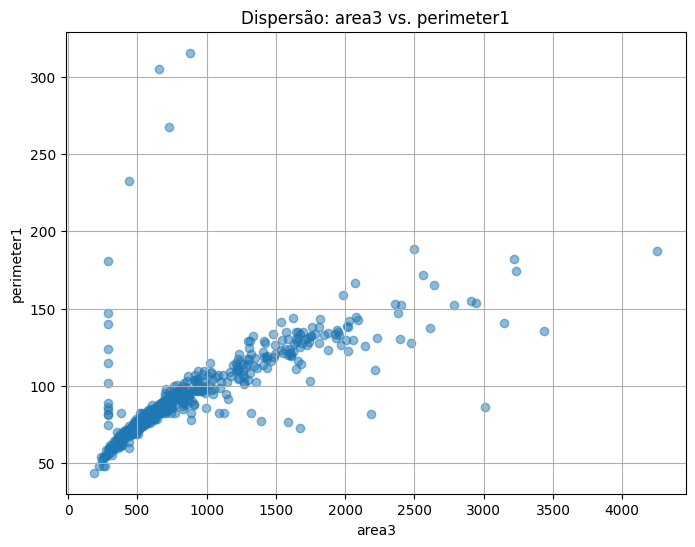

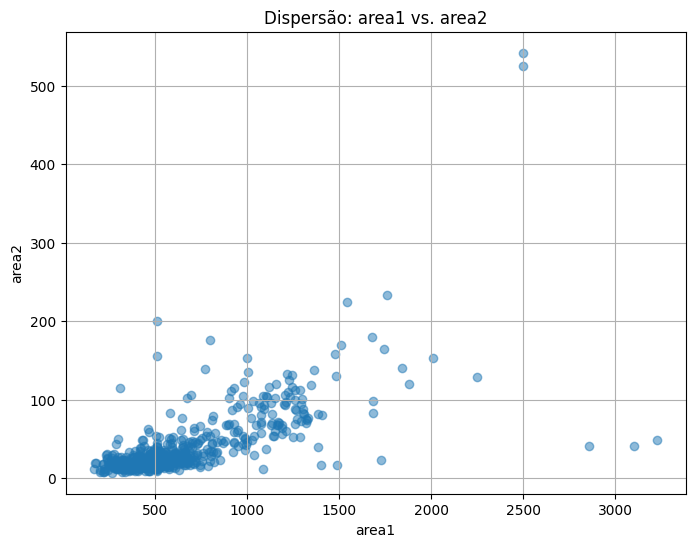

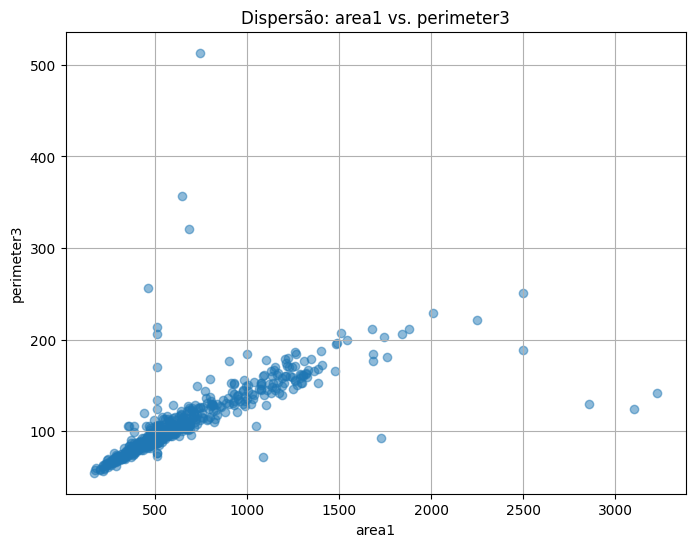

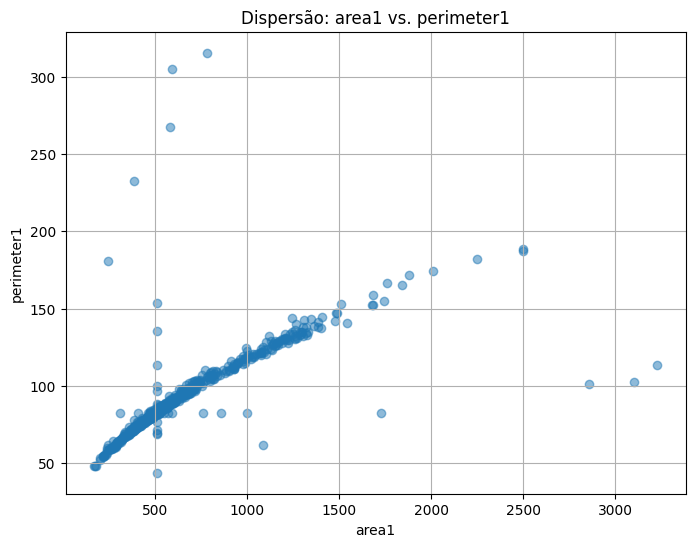

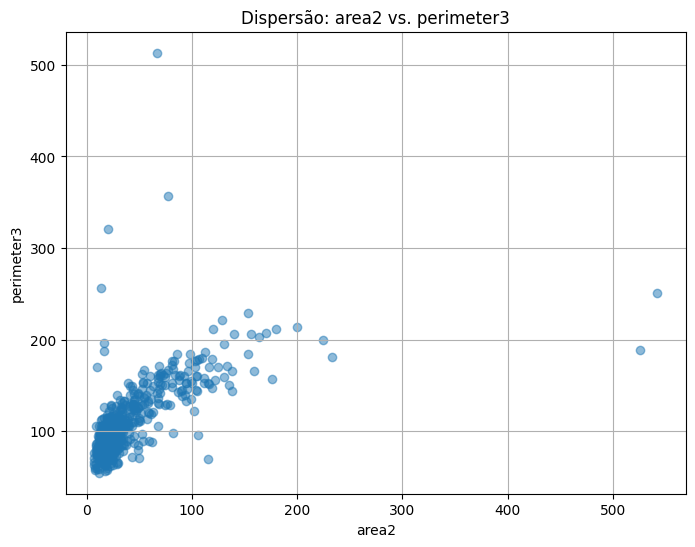

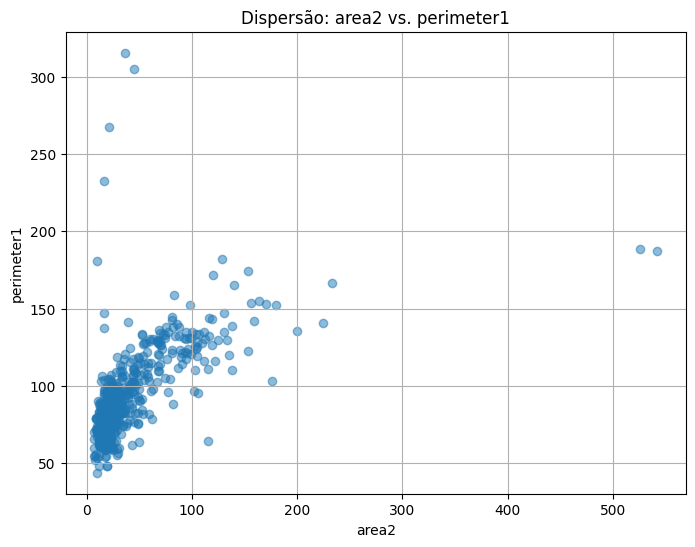

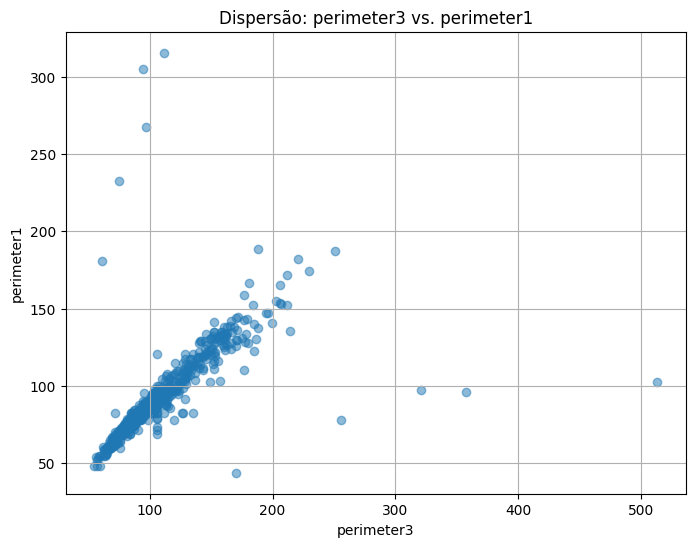

In [ ]:
# prompt: Exibir gráficos de dispersão entre pares de genes numéricos do dataset

colunas_numericas = df_sem_nulos.select_dtypes(include=np.number).columns.drop(['ID'], errors='ignore')

# Limita a quantidade de pares para o notebook não ficar excessivamente pesado
colunas_plot = list(colunas_numericas[:5])

for i in range(len(colunas_plot)):
    for j in range(i + 1, len(colunas_plot)):
        coluna1 = colunas_plot[i]
        coluna2 = colunas_plot[j]
        plt.figure(figsize=(8, 6))
        plt.scatter(df_sem_nulos[coluna1], df_sem_nulos[coluna2], alpha=0.5)
        plt.title(f'Dispersão: {coluna1} vs. {coluna2}')
        plt.xlabel(coluna1)
        plt.ylabel(coluna2)
        plt.grid(True)
        plt.show()


In [ ]:
# prompt: Selecionar apenas colunas numéricas; detectar outliers pelo método IQR;
# contar linhas únicas com pelo menos um outlier; calcular o percentual de contaminação

colunas_numericas = df_sem_nulos.select_dtypes(include=np.number).columns.drop(['ID'], errors='ignore')

indices_outliers = set()

for coluna in colunas_numericas:
    Q1 = df_sem_nulos[coluna].quantile(0.25)
    Q3 = df_sem_nulos[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mask = (df_sem_nulos[coluna] < limite_inferior) | (df_sem_nulos[coluna] > limite_superior)
    indices_outliers.update(df_sem_nulos[mask].index.tolist())

contador_outliers = len(indices_outliers)
percentual_contaminacao = contador_outliers / len(df_sem_nulos)

print(f"Número total de linhas com outliers: {contador_outliers}")
print(f"Percentual de contaminação por outliers: {percentual_contaminacao:.4f} ({percentual_contaminacao*100:.2f}%)")


Número total de linhas com outliers: 111
Percentual de contaminação por outliers: 0.1951 (19.51%)


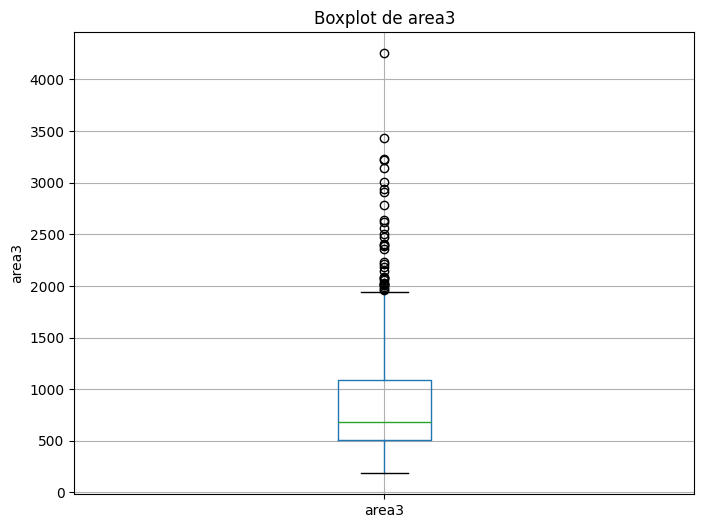

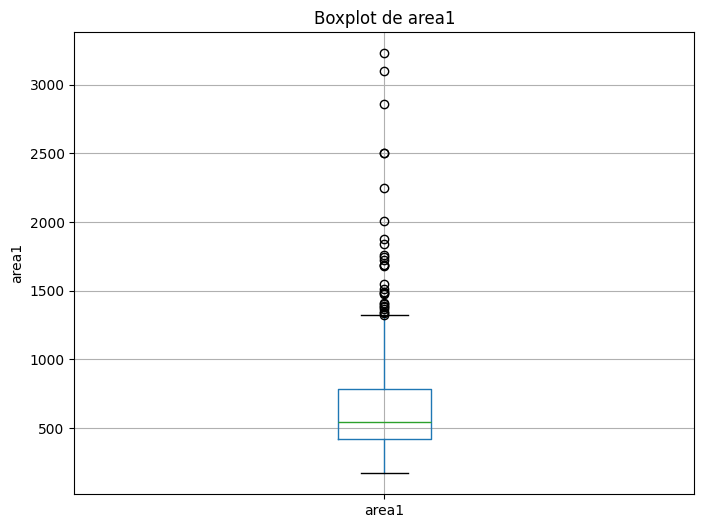

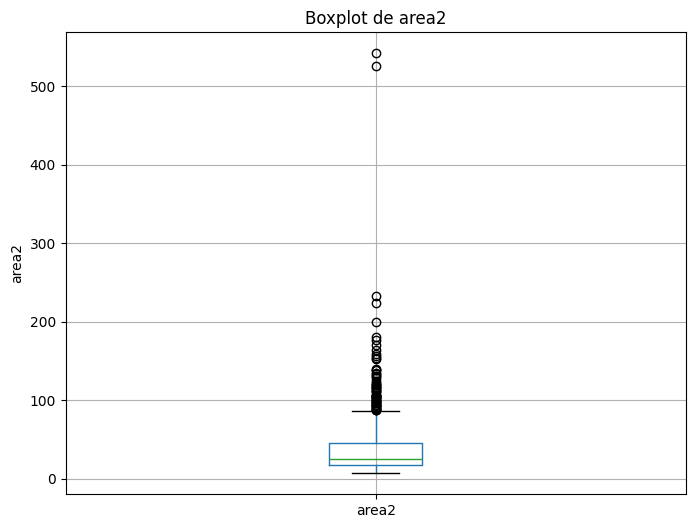

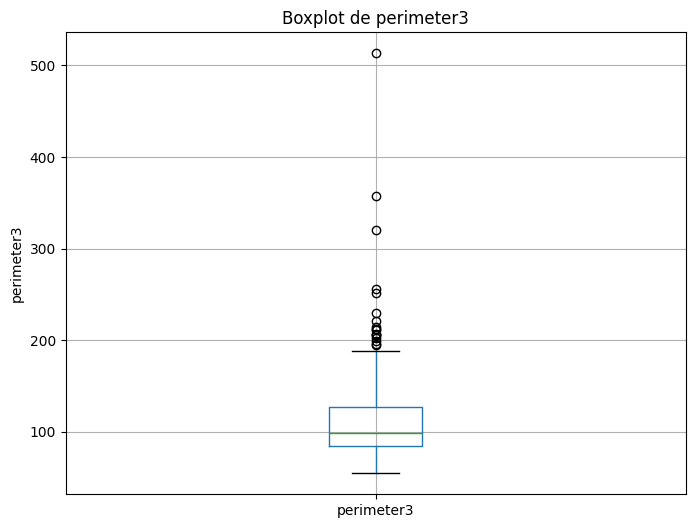

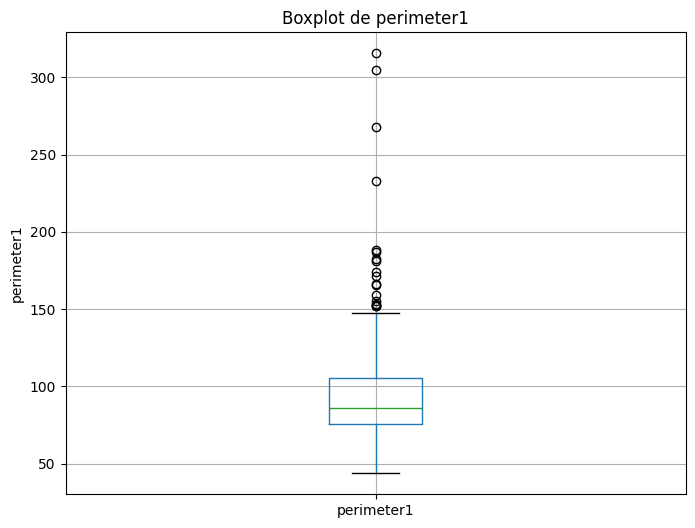

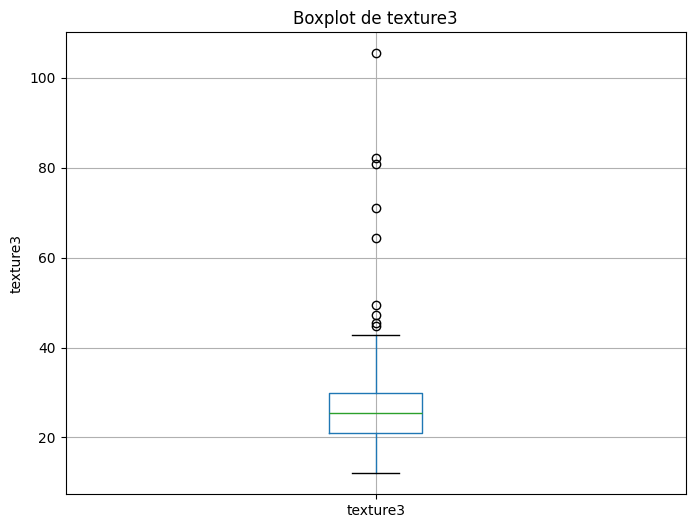

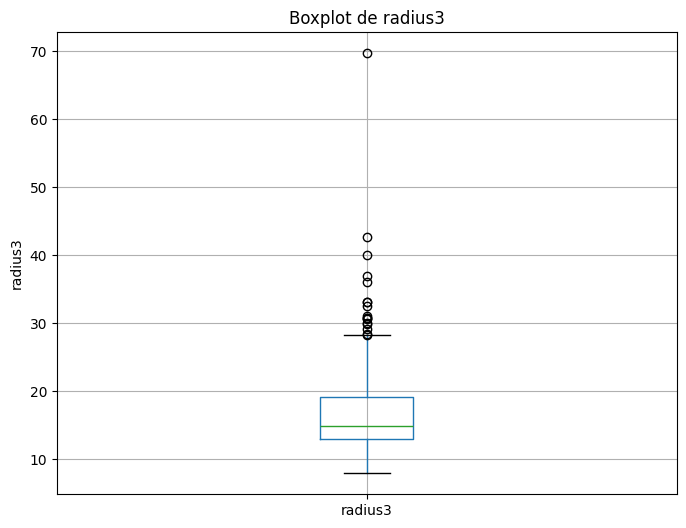

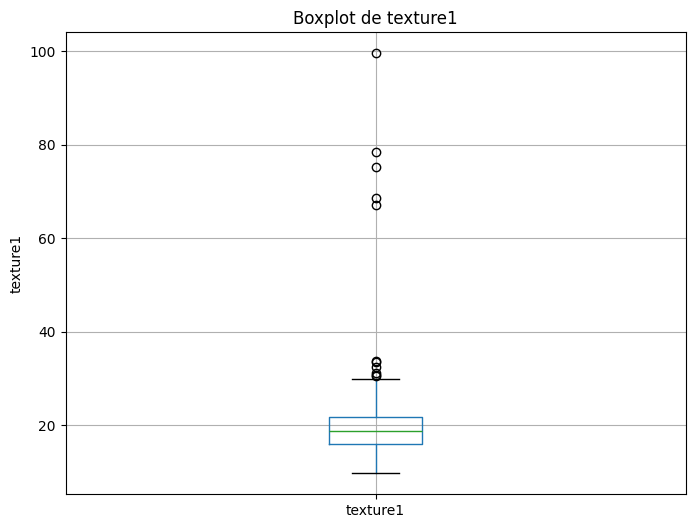

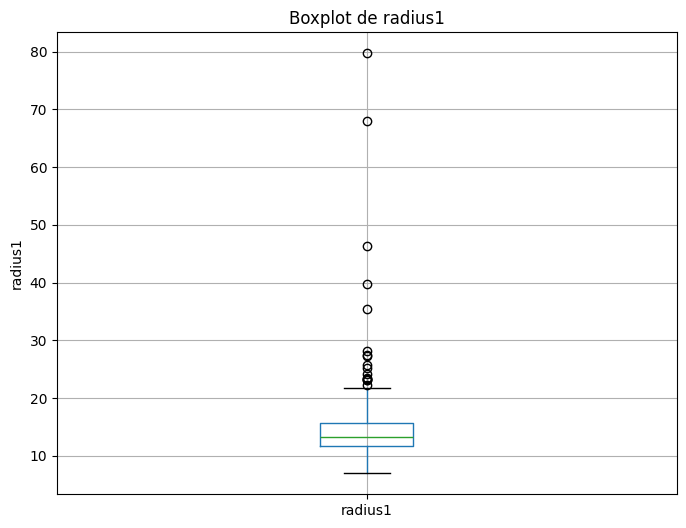

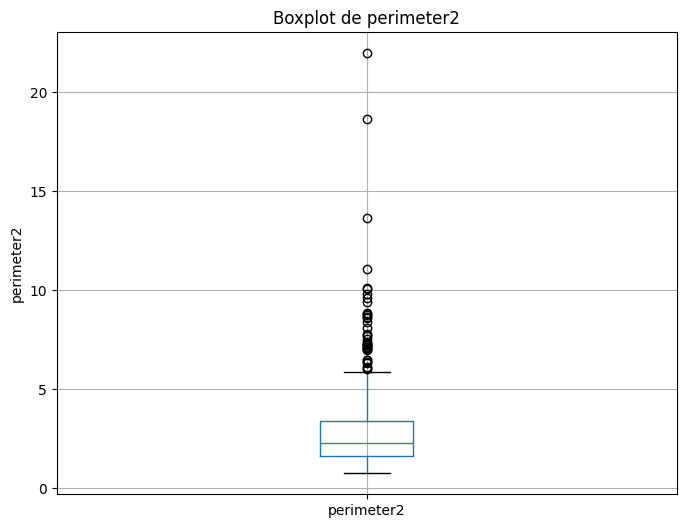

In [ ]:
# prompt: Exibir boxplot para cada coluna numérica para visualizar os outliers do dataset

# ... (código anterior permanece inalterado)

# Boxplot para cada coluna numérica
for coluna in colunas_numericas:
    plt.figure(figsize=(8, 6))
    df_sem_nulos.boxplot(column=[coluna])
    plt.title(f'Boxplot de {coluna}')
    plt.ylabel(coluna)
    plt.show()

In [ ]:
# prompt: Usando Isolation Forest com o percentual de contaminação calculado,
# obter inliers e outliers e exibir os dados

from sklearn.ensemble import IsolationForest

percentual_contaminacao = max(0.01, min(percentual_contaminacao, 0.2))

modelo_isolation_forest = IsolationForest(contamination=percentual_contaminacao, random_state=42)
modelo_isolation_forest.fit(df_sem_nulos[colunas_numericas])

previsoes = modelo_isolation_forest.predict(df_sem_nulos[colunas_numericas])
df_sem_nulos['Previsao'] = previsoes

print("Dados com previsões (1 = inlier, -1 = outlier):")
print(df_sem_nulos.head())

inliers = df_sem_nulos[df_sem_nulos['Previsao'] == 1]
outliers = df_sem_nulos[df_sem_nulos['Previsao'] == -1]

print("\nQuantidade de inliers:", len(inliers))
print("Quantidade de outliers:", len(outliers))
print("\nExemplo de outliers detectados:")
print(outliers.head())


Dados com previsões (1 = inlier, -1 = outlier):
   ID   area3   area1   area2  perimeter3  perimeter1  texture3  radius3  \
0   1  2019.0  1001.0  153.40      184.60      122.80     17.33    25.38   
1   2  1956.0  1326.0   74.08      158.80      132.90     23.41    24.99   
2   3  1709.0  1203.0   94.03      152.50      130.00     25.53    23.57   
3   4   567.7   386.1   27.23       98.87       77.58     26.50    14.91   
4   5  1575.0  1297.0   94.44      152.20      135.10     16.67    22.54   

   texture1  radius1  perimeter2 Tipo_Tumor  Previsao  
0     10.38    17.99       8.589          M        -1  
1     17.77    20.57       3.398          M        -1  
2     21.25    19.69       4.585          M         1  
3     20.38    11.42       3.445          M         1  
4     14.34    20.29       5.438          M        -1  

Quantidade de inliers: 458
Quantidade de outliers: 111

Exemplo de outliers detectados:
    ID   area3        area1   area2  perimeter3  perimeter1  texture3 

In [ ]:
# prompt: Contar quantos Outliers e Inliers existem no dataset

# Contar outliers e inliers
n_outliers = len(df_sem_nulos[df_sem_nulos['Previsao'] == -1])
n_inliers = len(df_sem_nulos[df_sem_nulos['Previsao'] == 1])

print(f"\nNúmero de outliers: {n_outliers}")
print(f"Número de inliers: {n_inliers}")


Número de outliers: 111
Número de inliers: 458


In [ ]:
# prompt: Usando MinMaxScaler, iterar pelas colunas numéricas do dataset, # adicionar novas colunas normalizadas com sufixo _minmax e exibir o novo dataset

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

colunas_numericas = df_sem_nulos.select_dtypes(include=np.number).columns.drop(['ID', 'Previsao'], errors='ignore')

df_normalizado = df_sem_nulos.copy()

for coluna in colunas_numericas:
    df_normalizado[f'{coluna}_minmax'] = scaler.fit_transform(df_sem_nulos[[coluna]])

df_normalizado.head()


,ID,area3,area1,area2,perimeter3,perimeter1,texture3,radius3,texture1,radius1,...,area3_minmax,area1_minmax,area2_minmax,perimeter3_minmax,perimeter1_minmax,texture3_minmax,radius3_minmax,texture1_minmax,radius1_minmax,perimeter2_minmax
0,1,2019.0,1001.0,153.40,184.60,122.80,17.33,25.38,10.38,17.99,...,0.450698,0.271594,0.273811,0.283557,0.290810,0.056821,0.282637,0.007455,0.151359,0.369034
1,2,1956.0,1326.0,74.08,158.80,132.90,23.41,24.99,17.77,20.57,...,0.435214,0.377864,0.125660,0.227329,0.327985,0.121881,0.276321,0.089684,0.186830,0.124440
2,3,1709.0,1203.0,94.03,152.50,130.00,25.53,23.57,21.25,19.69,...,0.374508,0.337645,0.162922,0.213599,0.317311,0.144566,0.253321,0.128407,0.174731,0.180370
3,4,567.7,386.1,27.23,98.87,77.58,26.50,14.91,20.38,11.42,...,0.094008,0.070531,0.038155,0.096720,0.124370,0.154946,0.113055,0.118726,0.061030,0.126655
4,5,1575.0,1297.0,94.44,152.20,135.10,16.67,22.54,14.34,20.29,...,0.341575,0.368381,0.163688,0.212945,0.336082,0.049758,0.236638,0.051518,0.182981,0.220563


In [ ]:
# prompt: Aplicar PCA com 2 componentes principais usando as colunas normalizadas

from sklearn.decomposition import PCA

colunas_para_pca = [col for col in df_normalizado.columns if col.endswith('_minmax')]
df_pca = df_normalizado[colunas_para_pca].fillna(0)

pca = PCA(n_components=2, random_state=42)
componentes_principais = pca.fit_transform(df_pca)

df_normalizado['pc1'] = componentes_principais[:, 0]
df_normalizado['pc2'] = componentes_principais[:, 1]

print("Variância explicada por PC1 e PC2:", pca.explained_variance_ratio_)
print(df_normalizado[['pc1', 'pc2']].head())


Variância explicada por PC1 e PC2: [0.6351152  0.09675396]
        pc1       pc2
0  0.456698 -0.225604
1  0.399412 -0.060697
2  0.363430 -0.032062
3 -0.123139  0.011356
4  0.360333 -0.153770


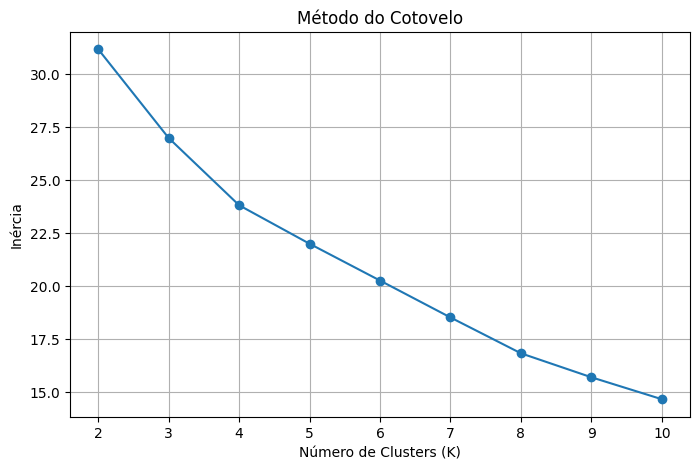

O melhor valor de K é: 2


In [ ]:
# prompt: Selecionar apenas as colunas com o sufixo "_minmax"; testar valores de K de 2 a 10; plotar o cotovelo e exibir o melhor valor de K

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

colunas_minmax = [col for col in df_normalizado.columns if col.endswith('_minmax')]
dados_clusterizacao = df_normalizado[colunas_minmax].fillna(0)

inercia = []

for k in range(2, 11):
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_teste.fit(dados_clusterizacao)
    inercia.append(kmeans_teste.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inercia, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.grid(True)
plt.show()

diferencas_inercia = [inercia[i] - inercia[i+1] for i in range(len(inercia)-1)]
melhor_k = diferencas_inercia.index(max(diferencas_inercia)) + 2

print(f"O melhor valor de K é: {melhor_k}")


In [ ]:
# prompt: Definir os hiperparâmetros do KMeans

n_clusters = melhor_k
max_iter = 300
random_state = 42

kmeans = KMeans(n_clusters=n_clusters, max_iter=max_iter, random_state=random_state, n_init=10)


In [ ]:
# prompt: Selecionar apenas as colunas com o sufixo "_minmax"; Substituir valores NaN por 0; Criar o modelo kmeans com os hiperparâmetros definidos; Ajustar o modelo aos dados; Obter os rótulos dos clusters para cada amostra; Adicionar os rótulos dos clusters ao dataset; Exibir os dados com os rótulos dos clusters

# Substituir valores NaN por 0
dados_clusterizacao = dados_clusterizacao.fillna(0)

# Ajustar o modelo aos dados
kmeans.fit(dados_clusterizacao)

# Obter os rótulos dos clusters para cada amostra
labels = kmeans.labels_

# Adicionar os rótulos dos clusters ao dataset
df_normalizado['cluster'] = labels

# Exibir os dados com os rótulos dos clusters
df_normalizado

,ID,area3,area1,area2,perimeter3,perimeter1,texture3,radius3,texture1,radius1,...,perimeter3_minmax,perimeter1_minmax,texture3_minmax,radius3_minmax,texture1_minmax,radius1_minmax,perimeter2_minmax,pc1,pc2,cluster
0,1,2019.0,1001.0,153.40,184.60,122.80,17.330000,25.380,10.38,17.99,...,0.283557,0.290810,0.056821,0.282637,0.007455,0.151359,0.369034,0.456698,-0.225604,0
1,2,1956.0,1326.0,74.08,158.80,132.90,23.410000,24.990,17.77,20.57,...,0.227329,0.327985,0.121881,0.276321,0.089684,0.186830,0.124440,0.399412,-0.060697,0
2,3,1709.0,1203.0,94.03,152.50,130.00,25.530000,23.570,21.25,19.69,...,0.213599,0.317311,0.144566,0.253321,0.128407,0.174731,0.180370,0.363430,-0.032062,0
3,4,567.7,386.1,27.23,98.87,77.58,26.500000,14.910,20.38,11.42,...,0.096720,0.124370,0.154946,0.113055,0.118726,0.061030,0.126655,-0.123139,0.011356,1
4,5,1575.0,1297.0,94.44,152.20,135.10,16.670000,22.540,14.34,20.29,...,0.212945,0.336082,0.049758,0.236638,0.051518,0.182981,0.220563,0.360333,-0.153770,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,565,2027.0,1479.0,158.70,166.10,142.00,26.400000,25.450,22.39,21.56,...,0.243239,0.361479,0.153876,0.283771,0.141092,0.200441,0.325873,0.561729,-0.061058,0
565,566,1731.0,1261.0,99.04,155.00,131.20,38.250000,23.690,28.25,20.13,...,0.219048,0.321728,0.280679,0.255265,0.206296,0.180781,0.209490,0.409265,0.112381,0
566,567,1124.0,858.1,48.55,126.70,82.61,34.120000,18.980,28.08,12.34,...,0.157372,0.142884,0.236485,0.178977,0.204405,0.073679,0.125713,0.090744,0.118483,1
567,568,284.4,1265.0,86.22,184.60,140.10,105.472019,25.740,29.33,20.60,...,0.283557,0.354486,1.000000,0.288468,0.218314,0.187243,0.236300,0.330364,0.689995,0


In [ ]:
# prompt: Contar a quantidade de exemplos por cluster; Exibir os resultados

# Contar a quantidade de exemplos por cluster
contagem_clusters = df_normalizado['cluster'].value_counts()

# Exibir os resultados
print("Quantidade de exemplos por cluster:")
contagem_clusters

Quantidade de exemplos por cluster:


,count
cluster,
1,434
0,135


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


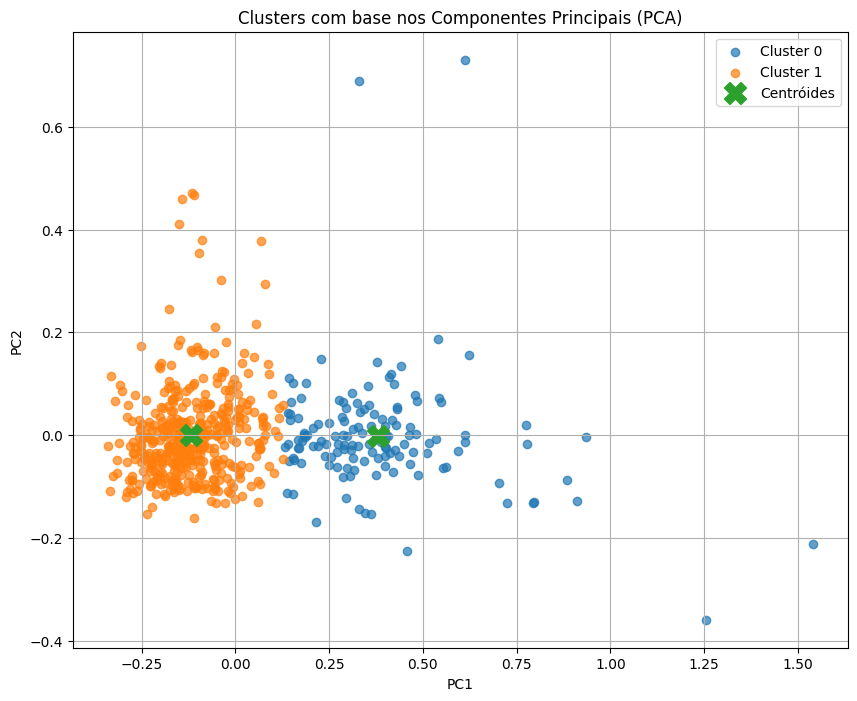

In [ ]:
# prompt: Plotar o gráfico dos clusters com base nos componentes principais (PCA)

plt.figure(figsize=(10, 8))

for cluster in sorted(df_normalizado['cluster'].unique()):
    dados_cluster = df_normalizado[df_normalizado['cluster'] == cluster]
    plt.scatter(dados_cluster['pc1'], dados_cluster['pc2'], label=f'Cluster {cluster}', alpha=0.7)

# Centróides projetados no espaço PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], s=250, marker='X', label='Centróides')

plt.title('Clusters com base nos Componentes Principais (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# prompt: Obter informações estatísticas para cada cluster

# Obter estatísticas descritivas para cada cluster
for cluster in df_normalizado['cluster'].unique():
    cluster_data = df_normalizado[df_normalizado['cluster'] == cluster]
    print(f"\nEstatísticas descritivas para o Cluster {cluster}:")
    print(cluster_data.describe())


Estatísticas descritivas para o Cluster 0:
               ID        area3        area1       area2  perimeter3  \
count  135.000000   135.000000   135.000000  135.000000  135.000000   
mean   245.074074  1695.258571  1200.914433   92.669185  160.719307   
std    165.824697   596.911543   432.952520   67.596517   43.629940   
min      1.000000   284.400000   512.200000   16.640000   94.520000   
25%    102.500000  1317.500000   981.050000   56.915000  140.200000   
50%    238.000000  1610.000000  1138.000000   80.990000  152.500000   
75%    371.500000  1942.000000  1295.000000  105.700000  170.300000   
max    568.000000  4254.000000  3228.644646  542.200000  513.339972   

       perimeter1    texture3     radius3    texture1     radius1  ...  \
count  135.000000  135.000000  135.000000  135.000000  135.000000  ...   
mean   131.189674   29.130015   23.768592   22.097486   19.767567  ...   
std     30.789802    8.632426    5.371471    7.649197    7.238911  ...   
min     82.610000   

In [ ]:
# prompt: Contar a quantidade de dados para cada classe; Obter a classe minoritária; Obter a classe majoritária; Separar os dados em conjuntos de acordo com a classe; Realizar o balanceamento por meio do método de reamostragem (upsampling/oversampling) da classe minoritária; Combinar os dados majoritários e os dados minoritários reamostrados; Verificar se o balanceamento foi realizado com sucesso

# ... (código anterior permanece inalterado)

# Contar a quantidade de dados para cada cluster
contagem_clusters = df_normalizado['cluster'].value_counts()
print("Quantidade de dados para cada cluster:")
print(contagem_clusters)

# Obter a classe minoritária
classe_minoritaria = contagem_clusters.idxmin()
print(f"\nClasse minoritária: {classe_minoritaria}")

# Obter a classe majoritária
classe_majoritaria = contagem_clusters.idxmax()
print(f"\nClasse majoritária: {classe_majoritaria}")

# Separar os dados em conjuntos de acordo com a classe
dados_minoritarios = df_normalizado[df_normalizado['cluster'] == classe_minoritaria]
dados_majoritarios = df_normalizado[df_normalizado['cluster'] == classe_majoritaria]

# Realizar o balanceamento por meio do método de reamostragem (upsampling/oversampling) da classe minoritária
from sklearn.utils import resample

dados_minoritarios_reamostrados = resample(dados_minoritarios,
                                          replace=True,  # sample with replacement
                                          n_samples=len(dados_majoritarios),  # match number in majority class
                                          random_state=42)  # reproducible results

# Combinar os dados majoritários e os dados minoritários reamostrados
dados_balanceados = pd.concat([dados_majoritarios, dados_minoritarios_reamostrados])

# Verificar se o balanceamento foi realizado com sucesso
contagem_clusters_balanceados = dados_balanceados['cluster'].value_counts()
print("\nQuantidade de dados para cada cluster após o balanceamento:")
contagem_clusters_balanceados

Quantidade de dados para cada cluster:
cluster
1    434
0    135
Name: count, dtype: int64

Classe minoritária: 0

Classe majoritária: 1

Quantidade de dados para cada cluster após o balanceamento:


,count
cluster,
1,434
0,434


In [ ]:
# prompt: Definir regras de atribuição para níveis de expressão gênica;
# aplicar as regras às colunas do dataset; exibir as regras de atribuição

regras_atribuicao = {}

# Seleciona dois genes normalizados para categorização automática
genes_para_regras = [col for col in df_normalizado.columns if col.endswith('_minmax')][:2]

for gene in genes_para_regras:
    q1 = df_normalizado[gene].quantile(0.33)
    q2 = df_normalizado[gene].quantile(0.66)

    regras_atribuicao[gene] = {
        'baixa_expressao': lambda x, q1=q1: x <= q1,
        'media_expressao': lambda x, q1=q1, q2=q2: (x > q1) and (x <= q2),
        'alta_expressao': lambda x, q2=q2: x > q2
    }

for coluna, regras in regras_atribuicao.items():
    if coluna in df_normalizado.columns:
        for categoria, regra in regras.items():
            df_normalizado[f'{coluna}_{categoria}'] = df_normalizado[coluna].apply(regra).astype(int)

print("Regras de Atribuição:")
for coluna, regras in regras_atribuicao.items():
    print(f"\nColuna: {coluna}")
    for categoria in regras.keys():
        print(f"  Categoria criada: {categoria}")

print("\nDataFrame com as novas colunas:")
print(df_normalizado.head())


Regras de Atribuição:

Coluna: area3_minmax
  Categoria criada: baixa_expressao
  Categoria criada: media_expressao
  Categoria criada: alta_expressao

Coluna: area1_minmax
  Categoria criada: baixa_expressao
  Categoria criada: media_expressao
  Categoria criada: alta_expressao

DataFrame com as novas colunas:
   ID   area3   area1   area2  perimeter3  perimeter1  texture3  radius3  \
0   1  2019.0  1001.0  153.40      184.60      122.80     17.33    25.38   
1   2  1956.0  1326.0   74.08      158.80      132.90     23.41    24.99   
2   3  1709.0  1203.0   94.03      152.50      130.00     25.53    23.57   
3   4   567.7   386.1   27.23       98.87       77.58     26.50    14.91   
4   5  1575.0  1297.0   94.44      152.20      135.10     16.67    22.54   

   texture1  radius1  ...  perimeter2_minmax       pc1       pc2  cluster  \
0     10.38    17.99  ...           0.369034  0.456698 -0.225604        0   
1     17.77    20.57  ...           0.124440  0.399412 -0.060697        0   

In [ ]:
# prompt: Separar os dados em treino e teste (80/20); exibir o tamanho dos conjuntos;
# apresentar o conteúdo dos conjuntos de treino e teste

from sklearn.model_selection import train_test_split

df_modelagem = df_normalizado.drop(columns=['Tipo_Tumor'], errors='ignore').copy()

if 'ID' in df_modelagem.columns:
    df_modelagem = df_modelagem.drop('ID', axis=1)

df_treino, df_teste = train_test_split(
    df_modelagem,
    test_size=0.2,
    random_state=42,
    stratify=df_modelagem['cluster']
)

print("Tamanho do conjunto de treino:", len(df_treino))
print("Tamanho do conjunto de teste:", len(df_teste))

print("\nConjunto de treino:")
print(df_treino.head())
print("\nConjunto de teste:")
print(df_teste.head())


Tamanho do conjunto de treino: 455
Tamanho do conjunto de teste: 114

Conjunto de treino:
      area3   area1   area2  perimeter3  perimeter1  texture3  radius3  \
85   1603.0  1075.0  80.600      152.20      121.10     27.68    22.93   
428   421.1   381.1   9.704       74.35       70.47     20.29    11.68   
481   830.5   602.9  16.640      104.40       88.73     26.42    16.41   
277  1236.0  1102.0  36.740      129.00      120.90     24.30    19.96   
185   437.0   317.5  26.430       75.39       63.76     21.18    11.87   

     texture1  radius1  perimeter2  ...  perimeter2_minmax       pc1  \
85      18.52    18.46       4.782  ...           0.189653  0.307875   
428     16.62    11.13       0.968  ...           0.009942 -0.236277   
481     19.24    13.90       2.056  ...           0.061207 -0.050084   
277     19.98    18.81       2.363  ...           0.075673  0.178056   
185     15.11    10.08       2.680  ...           0.090609 -0.222045   

          pc2  cluster  area3_mi

In [ ]:
# prompt: Definir os hiperparâmetros para o modelo MultiLayer Perceptron

from sklearn.neural_network import MLPClassifier

# Definir os hiperparâmetros para o modelo MLP
hidden_layer_sizes = (100, 50)  # Duas camadas ocultas com 100 e 50 neurônios
activation = 'relu'  # Função de ativação ReLU
solver = 'adam'  # Otimizador Adam
alpha = 0.0001  # Parâmetro de regularização L2
batch_size = 'auto'  # Tamanho do mini-batch automático
learning_rate = 'constant'  # Taxa de aprendizado constante
learning_rate_init = 0.001  # Taxa de aprendizado inicial
power_t = 0.5  # Expoente para a taxa de aprendizado (inverso)
max_iter = 200  # Número máximo de iterações
shuffle = True  # Embaralhar os dados a cada época
random_state = None  # Semente aleatória
tol = 0.0001  # Tolerância para a convergência
verbose = False  # Não exibir informações de treinamento
warm_start = False  # Não reiniciar o treinamento com os pesos anteriores
momentum = 0.9  # Momento para o otimizador
nesterovs_momentum = True  # Usar o momento de Nesterov
early_stopping = False  # Não usar parada antecipada
validation_fraction = 0.1  # Fração dos dados para validação (parada antecipada)
beta_1 = 0.9  # Parâmetro beta_1 para o otimizador Adam
beta_2 = 0.999  # Parâmetro beta_2 para o otimizador Adam
epsilon = 1e-08  # Parâmetro epsilon para o otimizador Adam
n_iter_no_change = 10  # Número máximo de épocas sem melhora (parada antecipada)
max_fun = 15000  # Número máximo de chamadas à função de perda

# Criar o modelo MLP com os hiperparâmetros definidos
mlp_model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation=activation, solver=solver,
                         alpha=alpha, batch_size=batch_size, learning_rate=learning_rate,
                         learning_rate_init=learning_rate_init, power_t=power_t, max_iter=max_iter,
                         shuffle=shuffle, random_state=random_state, tol=tol, verbose=verbose,
                         warm_start=warm_start, momentum=momentum, nesterovs_momentum=nesterovs_momentum,
                         early_stopping=early_stopping, validation_fraction=validation_fraction,
                         beta_1=beta_1, beta_2=beta_2, epsilon=epsilon, n_iter_no_change=n_iter_no_change,
                         max_fun=max_fun)

# ... (código anterior permanece inalterado)

In [ ]:
# prompt: Definir os hiperparâmetros para o modelo Support Vector Machine

from sklearn.svm import SVC

# Definir os hiperparâmetros para o modelo SVM
C = 1.0  # Parâmetro de regularização
kernel = 'rbf'  # Kernel gaussiano (radial basis function)
degree = 3  # Grau do kernel polinomial (se usado)
gamma = 'scale'  # Parâmetro do kernel gaussiano ('scale' ou 'auto' ou um valor numérico)
coef0 = 0.0  # Constante independente para kernels polinomiais e sigmoid
shrinking = True  # Usar heurística de shrinking
probability = False  # Não calcular probabilidades
tol = 1e-3  # Tolerância para a convergência
cache_size = 200  # Tamanho do cache em MB
class_weight = None  # Nenhum peso de classe
verbose = False  # Não exibir informações de treinamento
max_iter = -1  # Número máximo de iterações (-1 para ilimitado)
decision_function_shape = 'ovr'  # Estratégia de decisão ('ovo' ou 'ovr')
break_ties = False # Não quebra empates
random_state = None  # Semente aleatória

# Criar o modelo SVM com os hiperparâmetros definidos
svm_model = SVC(C=C, kernel=kernel, degree=degree, gamma=gamma, coef0=coef0, shrinking=shrinking,
                probability=probability, tol=tol, cache_size=cache_size, class_weight=class_weight,
                verbose=verbose, max_iter=max_iter, decision_function_shape=decision_function_shape,
                break_ties=break_ties, random_state=random_state)

In [ ]:
# prompt: Treinar e avaliar o modelo com validação cruzada; Imprimir os resultados da validação cruzada; Treinar o modelo com os dados de treinamento completos; Fazer previsões com o modelo no conjunto de teste; Calcular as métricas de avaliação para o modelo MLP

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Separar features (X) e target (y)
X = df_treino.drop('cluster', axis=1)
y = df_treino['cluster']

# Definir o número de folds para a validação cruzada
n_splits = 5  # Número de folds (ajuste conforme necessário)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)


# Validação cruzada com o modelo MLP
scores_mlp = cross_val_score(mlp_model, X, y, cv=kf, scoring='accuracy') #scoring='f1_macro'

# Imprimir os resultados da validação cruzada para o modelo MLP
print("Resultados da Validação Cruzada (MLP):")
print("Acurácia para cada fold:", scores_mlp)
print("Acurácia média:", np.mean(scores_mlp))
print("Desvio padrão da acurácia:", np.std(scores_mlp))

# Treinar o modelo MLP com todos os dados de treinamento
mlp_model.fit(X, y)


# Fazer previsões com o modelo MLP no conjunto de teste
X_test = df_teste.drop('cluster', axis=1)
y_test = df_teste['cluster']
y_pred_mlp = mlp_model.predict(X_test)


# Calcular as métricas de avaliação para o modelo MLP
print("\nAvaliação do Modelo MLP no Conjunto de Teste:")
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred_mlp))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_mlp))
print("\nAcurácia:", accuracy_score(y_test, y_pred_mlp))

Resultados da Validação Cruzada (MLP):
Acurácia para cada fold: [0.89010989 0.97802198 0.93406593 0.91208791 0.97802198]
Acurácia média: 0.9384615384615383
Desvio padrão da acurácia: 0.035164835164835165

Avaliação do Modelo MLP no Conjunto de Teste:
Matriz de Confusão:
 [[23  4]
 [ 0 87]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92        27
           1       0.96      1.00      0.98        87

    accuracy                           0.96       114
   macro avg       0.98      0.93      0.95       114
weighted avg       0.97      0.96      0.96       114


Acurácia: 0.9649122807017544


In [ ]:
# prompt: Treinar e avaliar o modelo com validação cruzada; Imprimir os resultados da validação cruzada; Treinar o modelo com os dados de treinamento completos; Fazer previsões com o modelo no conjunto de teste; Calcular as métricas de avaliação para o modelo SVM

# Validação cruzada com o modelo SVM
scores_svm = cross_val_score(svm_model, X, y, cv=kf, scoring='accuracy')

# Imprimir os resultados da validação cruzada para o modelo SVM
print("\nResultados da Validação Cruzada (SVM):")
print("Acurácia para cada fold:", scores_svm)
print("Acurácia média:", np.mean(scores_svm))
print("Desvio padrão da acurácia:", np.std(scores_svm))

# Treinar o modelo SVM com todos os dados de treinamento
svm_model.fit(X, y)

# Fazer previsões com o modelo SVM no conjunto de teste
y_pred_svm = svm_model.predict(X_test)

# Calcular as métricas de avaliação para o modelo SVM
print("\nAvaliação do Modelo SVM no Conjunto de Teste:")
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred_svm))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_svm))
print("\nAcurácia:", accuracy_score(y_test, y_pred_svm))


Resultados da Validação Cruzada (SVM):
Acurácia para cada fold: [0.94505495 0.96703297 0.98901099 0.97802198 0.96703297]
Acurácia média: 0.9692307692307691
Desvio padrão da acurácia: 0.014578570507056717

Avaliação do Modelo SVM no Conjunto de Teste:
Matriz de Confusão:
 [[25  2]
 [ 1 86]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94        27
           1       0.98      0.99      0.98        87

    accuracy                           0.97       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.97      0.97       114


Acurácia: 0.9736842105263158


In [ ]:
# prompt: Verificar qual o modelo campeão; Salvar o modelo; Carregar o modelo e usar os dados de teste para validar exibindo as métricas

import joblib

# Comparar as métricas de avaliação dos modelos MLP e SVM
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

if accuracy_mlp > accuracy_svm:
  champion_model = mlp_model
  champion_model_name = "MLP"
  print(f"\nO modelo campeão é o {champion_model_name}, com acurácia: {accuracy_mlp}")
else:
  champion_model = svm_model
  champion_model_name = "SVM"
  print(f"\nO modelo campeão é o {champion_model_name}, com acurácia: {accuracy_svm}")


# Salvar o modelo campeão
filename = 'champion_model.sav'
joblib.dump(champion_model, filename)
print(f"Modelo campeão salvo em {filename}")


# Carregar o modelo
loaded_model = joblib.load(filename)

# Usar os dados de teste para validar o modelo carregado
y_pred_loaded = loaded_model.predict(X_test)

# Calcular as métricas de avaliação para o modelo carregado
print("\nAvaliação do Modelo Carregado no Conjunto de Teste:")
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred_loaded))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_loaded))
print("\nAcurácia:", accuracy_score(y_test, y_pred_loaded))


O modelo campeão é o SVM, com acurácia: 0.9736842105263158
Modelo campeão salvo em champion_model.sav

Avaliação do Modelo Carregado no Conjunto de Teste:
Matriz de Confusão:
 [[25  2]
 [ 1 86]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94        27
           1       0.98      0.99      0.98        87

    accuracy                           0.97       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.97      0.97       114


Acurácia: 0.9736842105263158
